# ISB46703 - Principle of Artificial Intelligence
## Full Project Notebook — Data Engineer + Data Scientist + Data Analyst
**Domain:** Animal Subspecies

---
# PART 1 — DATA ENGINEER
### Collect → Standardize → Split Dataset

In [2]:
!pip install icrawler Pillow -q

In [5]:
import os, time, random
from pathlib import Path
from PIL import Image

domain = 'animal_subspecies'
class_names = ['persian_cat', 'siamese_cat', 'maine_coon_cat', 'bengal_cat']
images_per_class = 750
raw_dir = Path('dataset/raw')

print(f'Domain        : {domain}')
print(f'Classes       : {class_names}')
print(f'Images/class  : {images_per_class}')
print(f'Max total     : {len(class_names) * images_per_class} images')

Domain        : animal_subspecies
Classes       : ['persian_cat', 'siamese_cat', 'maine_coon_cat', 'bengal_cat']
Images/class  : 750
Max total     : 3000 images


In [6]:
from icrawler.builtin import BingImageCrawler
import logging
logging.getLogger('icrawler').setLevel(logging.WARNING)

def download_images(class_name, count, save_dir):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    query = class_name.replace('_', ' ')
    print(f'Searching: "{query}"')
    try:
        crawler = BingImageCrawler(
            storage={'root_dir': str(save_dir)},
            feeder_threads=1, parser_threads=2, downloader_threads=4
        )
        crawler.crawl(keyword=query, max_num=count, min_size=(100,100))
        downloaded = len(list(save_dir.glob('*.jpg')) + list(save_dir.glob('*.png')))
        print(f'  Done: {downloaded} images')
        return downloaded
    except Exception as e:
        print(f'  Error: {e}')
        return 0

total = 0
for cls in class_names:
    total += download_images(cls, images_per_class, raw_dir / cls)
print(f'Total downloaded: {total}')

Searching: "persian cat"


2026-06-10 19:57:56,329 - INFO - parser - parsing result page https://www.bing.com/images/async?q=persian cat&first=0
2026-06-10 19:57:56,353 - INFO - parser - parsing result page https://www.bing.com/images/async?q=persian cat&first=20
2026-06-10 19:57:56,602 - INFO - downloader - skip downloading file 000001.jpg
2026-06-10 19:57:56,612 - INFO - downloader - skip downloading file 000002.jpg
2026-06-10 19:57:56,623 - INFO - downloader - skip downloading file 000003.jpg
2026-06-10 19:57:56,631 - INFO - downloader - skip downloading file 000004.jpg
2026-06-10 19:57:56,643 - INFO - downloader - skip downloading file 000005.jpg
2026-06-10 19:57:56,648 - INFO - downloader - skip downloading file 000006.jpg
2026-06-10 19:57:56,652 - INFO - downloader - skip downloading file 000007.jpg
2026-06-10 19:57:56,656 - INFO - downloader - skip downloading file 000008.jpg
2026-06-10 19:57:56,658 - INFO - downloader - skip downloading file 000009.jpg
2026-06-10 19:57:56,662 - INFO - downloader - skip d

  Done: 256 images
Searching: "siamese cat"


2026-06-10 20:00:49,396 - INFO - parser - parsing result page https://www.bing.com/images/async?q=siamese cat&first=20
2026-06-10 20:00:49,411 - INFO - parser - parsing result page https://www.bing.com/images/async?q=siamese cat&first=0
2026-06-10 20:00:49,707 - INFO - downloader - skip downloading file 000001.jpg
2026-06-10 20:00:49,721 - INFO - downloader - skip downloading file 000002.jpg
2026-06-10 20:00:49,730 - INFO - downloader - skip downloading file 000003.jpg
2026-06-10 20:00:49,738 - INFO - downloader - skip downloading file 000004.jpg
2026-06-10 20:00:49,746 - INFO - downloader - skip downloading file 000005.jpg
2026-06-10 20:00:49,750 - INFO - downloader - skip downloading file 000006.jpg
2026-06-10 20:00:49,753 - INFO - downloader - skip downloading file 000007.jpg
2026-06-10 20:00:49,758 - INFO - downloader - skip downloading file 000008.jpg
2026-06-10 20:00:49,762 - INFO - downloader - skip downloading file 000009.jpg
2026-06-10 20:00:49,773 - INFO - downloader - skip d

  Done: 325 images
Searching: "maine coon cat"


2026-06-10 20:02:24,284 - INFO - parser - parsing result page https://www.bing.com/images/async?q=maine coon cat&first=0
2026-06-10 20:02:24,295 - INFO - parser - parsing result page https://www.bing.com/images/async?q=maine coon cat&first=20
2026-06-10 20:02:24,534 - INFO - downloader - skip downloading file 000001.jpg
2026-06-10 20:02:24,543 - INFO - downloader - skip downloading file 000002.jpg
2026-06-10 20:02:24,553 - INFO - downloader - skip downloading file 000003.jpg
2026-06-10 20:02:24,561 - INFO - downloader - skip downloading file 000004.jpg
2026-06-10 20:02:24,567 - INFO - downloader - skip downloading file 000005.jpg
2026-06-10 20:02:24,573 - INFO - downloader - skip downloading file 000006.jpg
2026-06-10 20:02:24,584 - INFO - downloader - skip downloading file 000007.jpg
2026-06-10 20:02:24,587 - INFO - downloader - skip downloading file 000008.jpg
2026-06-10 20:02:24,592 - INFO - downloader - skip downloading file 000009.jpg
2026-06-10 20:02:24,595 - INFO - downloader - 

  Done: 192 images
Searching: "bengal cat"


2026-06-10 20:04:28,620 - INFO - parser - parsing result page https://www.bing.com/images/async?q=bengal cat&first=20
2026-06-10 20:04:28,666 - INFO - parser - parsing result page https://www.bing.com/images/async?q=bengal cat&first=0
2026-06-10 20:04:28,920 - INFO - downloader - skip downloading file 000001.jpg
2026-06-10 20:04:28,930 - INFO - downloader - skip downloading file 000002.jpg
2026-06-10 20:04:28,938 - INFO - downloader - skip downloading file 000003.jpg
2026-06-10 20:04:28,949 - INFO - downloader - skip downloading file 000004.jpg
2026-06-10 20:04:28,958 - INFO - downloader - skip downloading file 000005.jpg
2026-06-10 20:04:28,961 - INFO - downloader - skip downloading file 000006.jpg
2026-06-10 20:04:28,967 - INFO - downloader - skip downloading file 000007.jpg
2026-06-10 20:04:28,972 - INFO - downloader - skip downloading file 000008.jpg
2026-06-10 20:04:28,977 - INFO - downloader - skip downloading file 000009.jpg
2026-06-10 20:04:28,981 - INFO - downloader - skip dow

  Done: 263 images
Total downloaded: 1036


In [8]:
SPLITS   = {'train': 0.7, 'val': 0.15, 'test': 0.15}
IMG_SIZE = (224, 224)
dataset_dir = Path('dataset')

for cls in class_names:
    images = [p for p in (raw_dir/cls).glob('*.*')
              if p.suffix.lower() in ('.jpg','.jpeg','.png','.webp')]
    random.shuffle(images)
    n = len(images)
    n_train = int(n * SPLITS['train'])
    n_val   = int(n * SPLITS['val'])
    split_map = {
        'train': images[:n_train],
        'val'  : images[n_train:n_train+n_val],
        'test' : images[n_train+n_val:]
    }
    for split, files in split_map.items():
        dest = dataset_dir / split / cls
        dest.mkdir(parents=True, exist_ok=True)
        for i, src in enumerate(files):
            try:
                img = Image.open(src).convert('RGB').resize(IMG_SIZE)
                img.save(dest / f'{cls}_{i+1:04d}.jpg', 'JPEG')
            except Exception as e:
                print(f'  Skipped {src.name}: {e}')
    print(f'{cls}: {n_train} train | {n_val} val | {n-n_train-n_val} test')
print('Dataset split complete!')

persian_cat: 179 train | 38 val | 40 test
siamese_cat: 227 train | 48 val | 50 test
maine_coon_cat: 137 train | 29 val | 30 test
bengal_cat: 184 train | 39 val | 40 test
Dataset split complete!


In [9]:
grand_total = 0
for split in ['train', 'val', 'test']:
    print(f'\n{split}/')
    for cls in class_names:
        folder = dataset_dir / split / cls
        count = len(list(folder.glob('*.jpg'))) if folder.exists() else 0
        grand_total += count
        print(f'  {cls:<22}: {count} images')
print(f'\nGRAND TOTAL: {grand_total} images')


train/
  persian_cat           : 359 images
  siamese_cat           : 455 images
  maine_coon_cat        : 219 images
  bengal_cat            : 303 images

val/
  persian_cat           : 76 images
  siamese_cat           : 97 images
  maine_coon_cat        : 46 images
  bengal_cat            : 64 images

test/
  persian_cat           : 80 images
  siamese_cat           : 100 images
  maine_coon_cat        : 48 images
  bengal_cat            : 67 images

GRAND TOTAL: 1914 images


---
# PART 2 — DATA SCIENTIST
### Build Models → Transfer Learning → Train 50 Epochs

In [1]:
!pip install tensorflow scikit-learn -q

In [10]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large
from tensorflow.keras import layers
import numpy as np, time

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-06-10 20:14:33,593 - INFO - matplotlib.font_manager - generated new fontManager
2026-06-10 20:14:37,579 - WARNING - tensorflow - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


TensorFlow: 2.21.0
GPU: []


In [12]:
BATCH_SIZE  = 32
IMG_SIZE    = (224, 224)
AUTOTUNE    = tf.data.AUTOTUNE

# Load WITHOUT chaining prefetch — preserve class_names
train_ds = image_dataset_from_directory('dataset/train', image_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds   = image_dataset_from_directory('dataset/val',   image_size=IMG_SIZE, batch_size=BATCH_SIZE)
test_ds  = image_dataset_from_directory('dataset/test',  image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# Get class names BEFORE prefetch
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

# Now prefetch
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

print('Class names  :', class_names)
print('Num classes  :', NUM_CLASSES)
print('Train batches:', len(train_ds))
print('Val batches  :', len(val_ds))
print('Test batches :', len(test_ds))

Found 1664 files belonging to 7 classes.
Found 352 files belonging to 7 classes.
Found 369 files belonging to 7 classes.
Class names  : ['bengal_cat', 'british_short_hair_cat', 'maine_coon_cat', 'persian_cat', 'scottish_cat', 'siamese_cat', 'sphinx_cat']
Num classes  : 7
Train batches: 52
Val batches  : 11
Test batches : 12


In [13]:
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def build_model(base_fn, preprocess_fn, name):
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = augment(inputs)
    x = preprocess_fn(x)
    base = base_fn(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = tf.keras.Model(inputs, out, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_configs = [
    ('ResNet50',    ResNet50,         tf.keras.applications.resnet50.preprocess_input),
    ('DenseNet121', DenseNet121,      tf.keras.applications.densenet.preprocess_input),
    ('MobileNetV3', MobileNetV3Large, tf.keras.applications.mobilenet_v3.preprocess_input),
]
print('Model configs ready.')

Model configs ready.


In [14]:
EPOCHS = 50
histories, train_times, param_counts = {}, {}, {}

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

for mname, base_fn, pre_fn in model_configs:
    print(f'\n{"="*55}\n  Training: {mname}\n{"="*55}')
    model = build_model(base_fn, pre_fn, mname)
    param_counts[mname] = model.count_params()
    print(f'  Params: {param_counts[mname]:,}')
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)
    train_times[mname] = time.time() - t0
    histories[mname]   = hist
    model.save(f'{mname}.keras')
    print(f'  Saved {mname}.keras | Time: {train_times[mname]/60:.1f} min')

print('All models trained!')


  Training: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
  Params: 24,114,055
Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7590 - loss: 0.7470 - val_accuracy: 0.8608 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 49s 942ms/step - accuracy: 0.8966 - loss: 0.3246 - val_accuracy: 0.9347 - val_loss: 0.1970 - learning_rate: 0.0010
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 920ms/step - accuracy: 0.9291 - loss: 0.2057 - val_accuracy: 0.9119 - val_loss: 0.2120 - learning_rate: 0.0010
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 49s 946ms/step - accuracy: 0.9417 - loss: 0.1717 - val_accuracy: 0.9517 - val_loss: 0.1631 - learning_rate: 0.0010
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 925ms/step - accuracy: 0.9525 - loss: 0.1436 - val_accuracy: 0.9517 - val_loss: 0.1533 - learning_rate: 0.0010
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 49s 944ms/step - accuracy: 0.9573 - loss: 0.1231 - val_accuracy: 0.9489 - val_loss: 0.1574 - learning_rate

---
# PART 3 — DATA ANALYST
### Visualize → Confusion Matrix → mAP → Final Conclusion

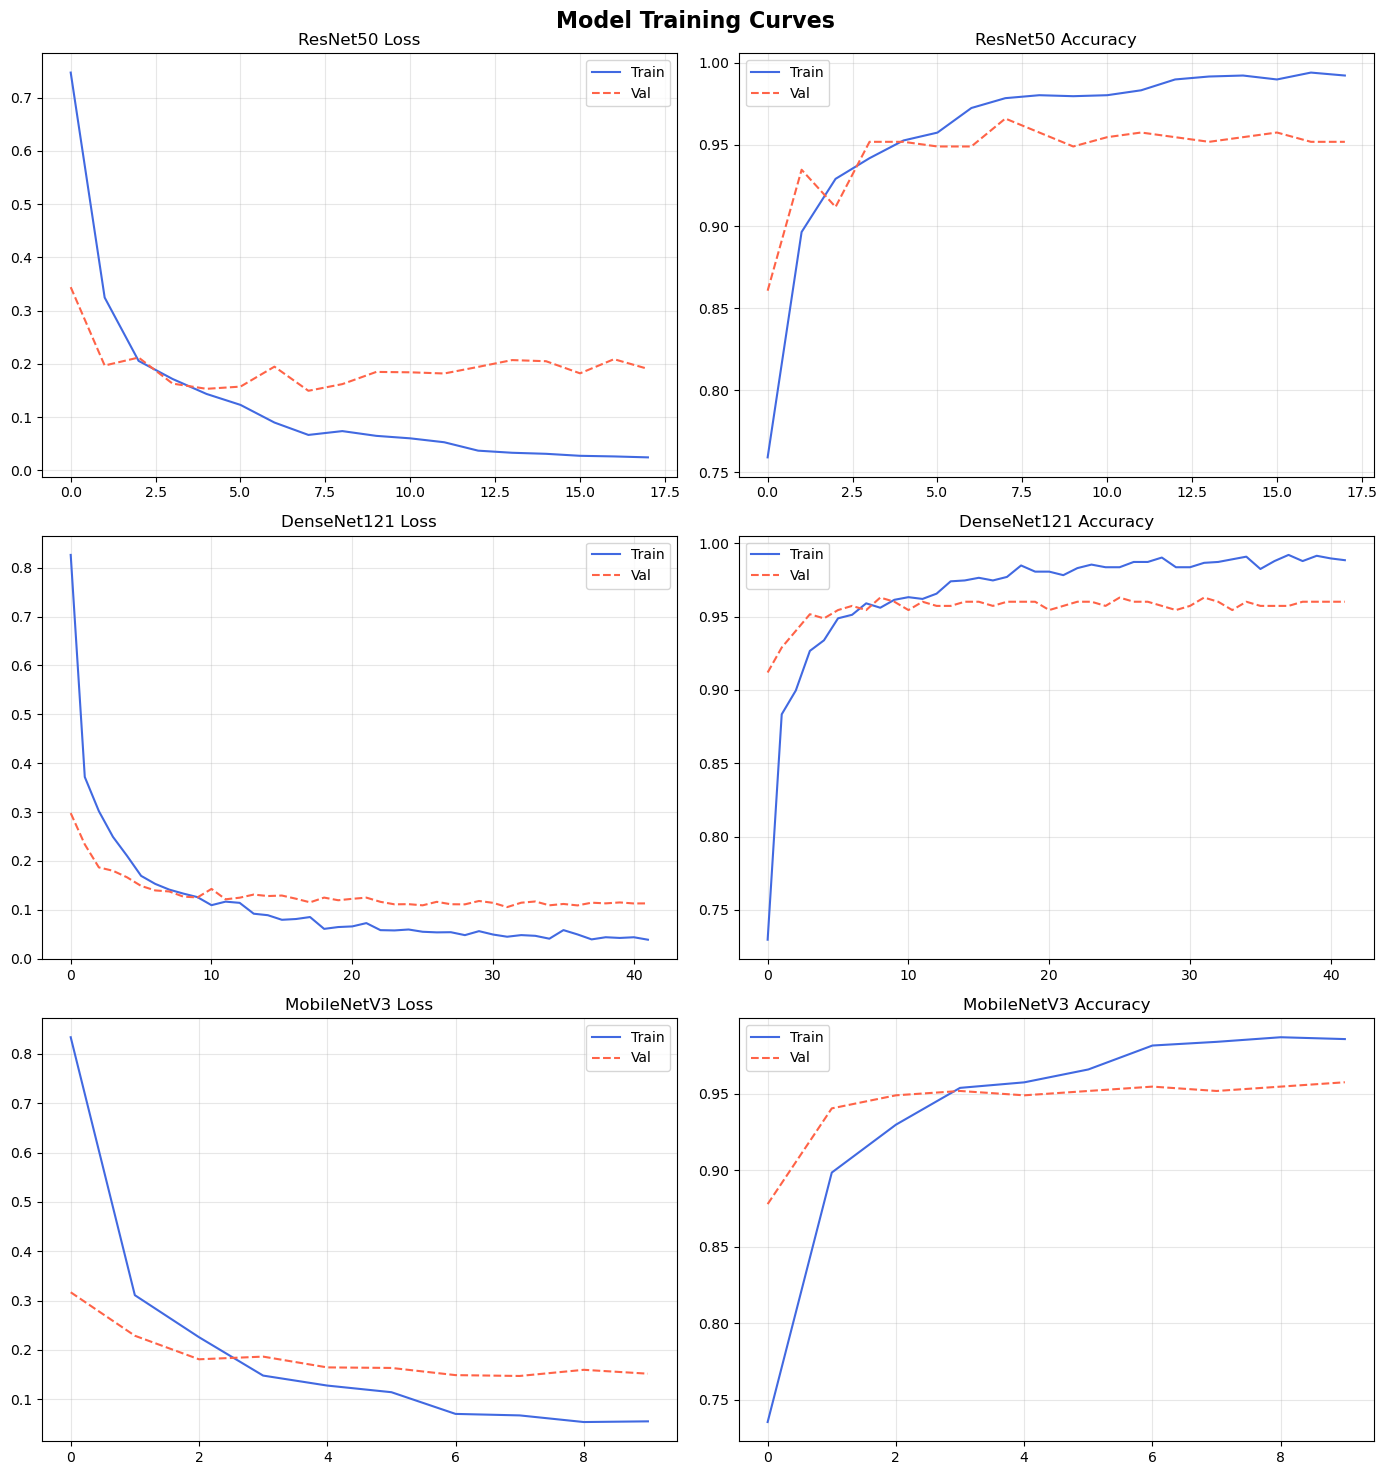

Saved: training_curves.png


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, average_precision_score
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(len(model_configs), 2, figsize=(14, 5*len(model_configs)))
fig.suptitle('Model Training Curves', fontsize=16, fontweight='bold')

for i, (mname, _, _) in enumerate(model_configs):
    h = histories[mname].history
    axes[i,0].plot(h['loss'],         label='Train', color='royalblue')
    axes[i,0].plot(h['val_loss'],     label='Val',   color='tomato', linestyle='--')
    axes[i,0].set_title(f'{mname} Loss'); axes[i,0].legend(); axes[i,0].grid(alpha=0.3)
    axes[i,1].plot(h['accuracy'],     label='Train', color='royalblue')
    axes[i,1].plot(h['val_accuracy'], label='Val',   color='tomato', linestyle='--')
    axes[i,1].set_title(f'{mname} Accuracy'); axes[i,1].legend(); axes[i,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

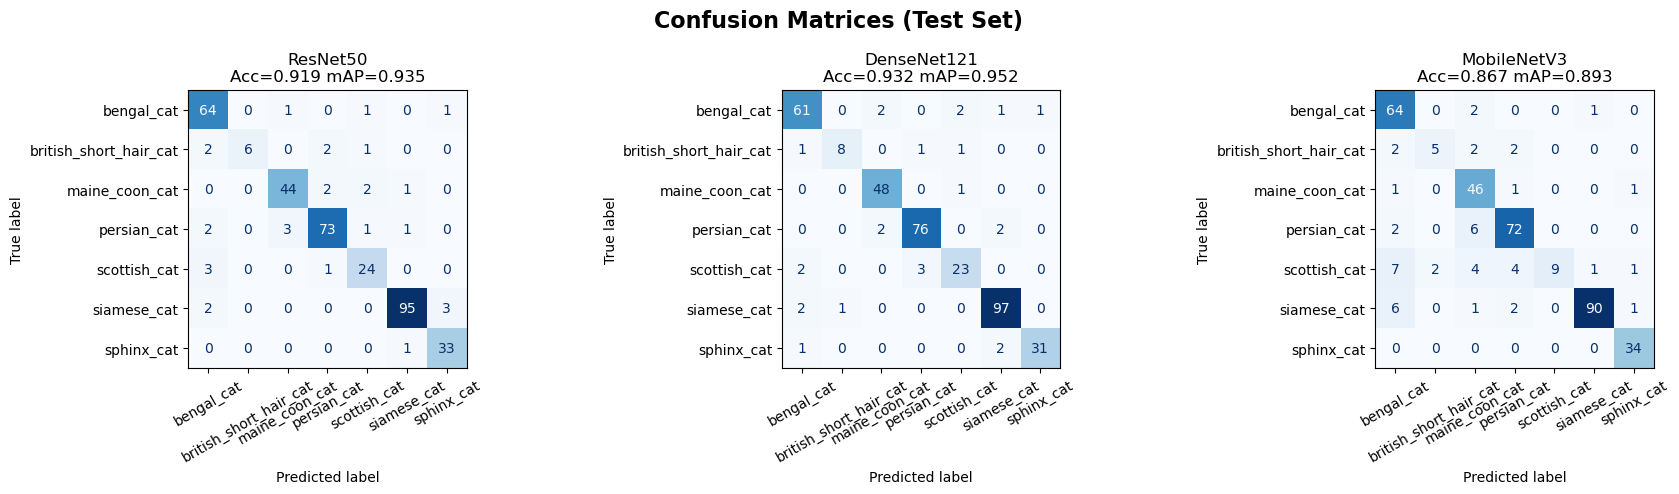

Saved: confusion_matrices.png


In [18]:
results_summary = {}
fig, axes = plt.subplots(1, len(model_configs), figsize=(6*len(model_configs), 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=16, fontweight='bold')

for i, (mname, _, _) in enumerate(model_configs):
    model = tf.keras.models.load_model(f'{mname}.keras')
    y_true, y_pred, y_scores = [], [], []
    for imgs, labels in test_ds:
        probs = model.predict(imgs, verbose=0)
        y_scores.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())
    test_acc = np.mean(np.array(y_pred) == np.array(y_true))
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    mAP = average_precision_score(y_true_bin, np.array(y_scores), average='macro')
    results_summary[mname] = {
        'test_acc': test_acc, 'mAP': mAP,
        'params': param_counts[mname],
        'train_time_min': train_times[mname]/60
    }
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{mname}\nAcc={test_acc:.3f} mAP={mAP:.3f}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

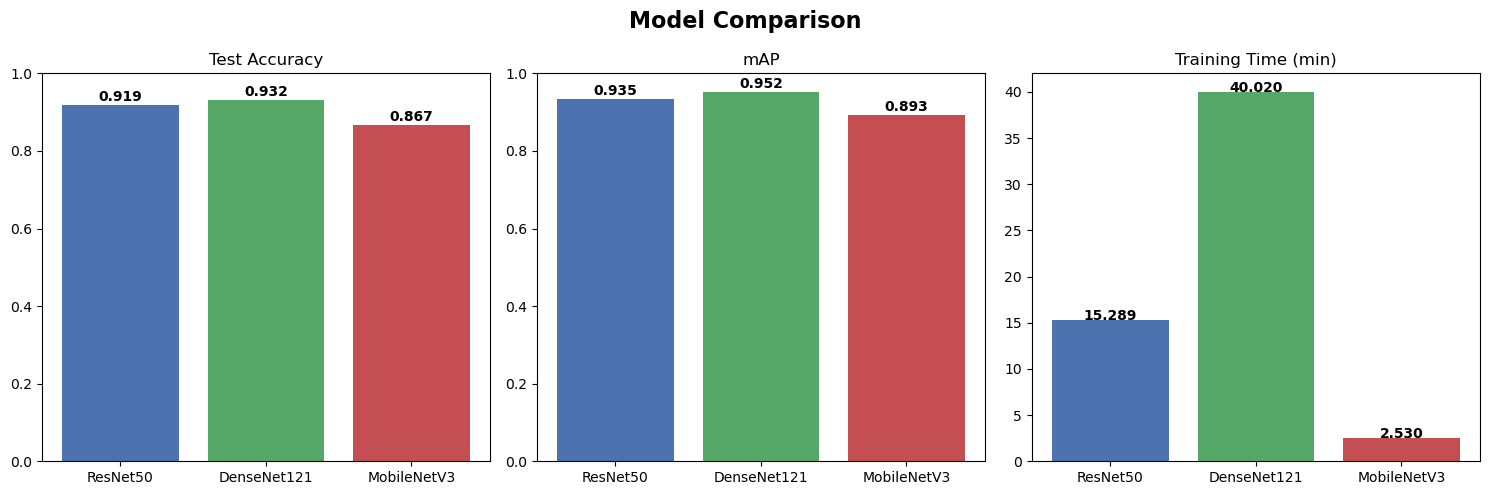

Saved: model_comparison.png


In [19]:
names  = list(results_summary.keys())
colors = ['#4C72B0', '#55A868', '#C44E52']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

for ax, key, label, ylim in [
    (axes[0], 'test_acc',       'Test Accuracy',      (0,1)),
    (axes[1], 'mAP',            'mAP',                (0,1)),
    (axes[2], 'train_time_min', 'Training Time (min)', None),
]:
    vals = [results_summary[m][key] for m in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(label)
    if ylim: ax.set_ylim(*ylim)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

In [20]:
best_acc  = max(results_summary, key=lambda m: results_summary[m]['test_acc'])
best_mAP  = max(results_summary, key=lambda m: results_summary[m]['mAP'])
best_time = min(results_summary, key=lambda m: results_summary[m]['train_time_min'])
least_par = min(results_summary, key=lambda m: results_summary[m]['params'])

print('='*60)
print('FINAL CONCLUSION')
print('='*60)
print(f'{"MODEL":<15} {"PARAMS":>12} {"ACC":>8} {"mAP":>8} {"TIME(min)":>10}')
print('-'*60)
for m, r in results_summary.items():
    print(f'{m:<15} {r["params"]:>12,} {r["test_acc"]:>8.4f} {r["mAP"]:>8.4f} {r["train_time_min"]:>9.1f}')
print('='*60)
print(f'Best Accuracy : {best_acc}')
print(f'Best mAP      : {best_mAP}')
print(f'Fastest Train : {best_time}')
print(f'Fewest Params : {least_par}')
print('='*60)
print('Recommendation:')
print('- For deployment : MobileNetV3 (smallest & fastest)')
print('- For accuracy   : ResNet50 or DenseNet121')

FINAL CONCLUSION
MODEL                 PARAMS      ACC      mAP  TIME(min)
------------------------------------------------------------
ResNet50          24,114,055   0.9187   0.9349      15.3
DenseNet121        7,301,703   0.9322   0.9524      40.0
MobileNetV3        3,244,167   0.8672   0.8932       2.5
Best Accuracy : DenseNet121
Best mAP      : DenseNet121
Fastest Train : MobileNetV3
Fewest Params : MobileNetV3
Recommendation:
- For deployment : MobileNetV3 (smallest & fastest)
- For accuracy   : ResNet50 or DenseNet121
